**Import Library**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from google.colab import files


1. pandas & numpy: Digunakan untuk memuat, membersihkan, dan memproses dataset.

2. train_test_split: Untuk membagi dataset menjadi train set dan test set.

3. TfidfVectorizer: Mengubah teks (headline) menjadi representasi numerik berbentuk TF-IDF vector.
Ini diperlukan karena Logistic Regression hanya bisa menerima angka, bukan teks.

4. LogisticRegression: Model dasar yang digunakan untuk klasifikasi.

5. MultiOutputClassifier
Digunakan karena kamu memprediksi dua label sekaligus:
*   Sentiment
*   Importance  
   Dengan ini, Logistic Regression bekerja untuk multi-label classification.

6. Pipeline: Menyatukan TF-IDF + Model jadi satu alur otomatis.

7. LabelEncoder: Mengubah kelas teks (positive, negative, major, minor) menjadi angka.

8. Metrics: Untuk evaluasi model: accuracy, precision, recall, f1-score, confusion matrix.

9. seaborn & matplotlib: Untuk visualisasi (heatmap confusion matrix).

10. joblib: Opsional, untuk menyimpan model jika dibutuhkan.

11. google.colab.files : Digunakan jika ingin upload / download file dari Google Colab.

**Upload Dataset**

In [ ]:
df = pd.read_csv("complete_labeled_dataset (1) - complete_labeled_dataset (1).csv")
df.head()

,headline,label,Importance,binary_label,confidence,source,label_name
0,Phillips 66 (PSX) Stock Sinks As Market Gains:...,Negative,major,1,1.0,original_labeled,major
1,5 Dirt Cheap Homebuilder Stocks in 2022,Neutral,minor,0,1.0,original_labeled,non-major
2,"Royal Caribbean, Carnival, Norwegian Near Pre-...",Positive,minor,0,1.0,original_labeled,non-major
3,ESG Rating Firms Reeling as War Exposes Russia...,Negative,minor,0,1.0,original_labeled,non-major
4,Alpa Sutaria Joins WestRock as Senior Vice Pre...,Neutral,minor,0,1.0,original_labeled,non-major


Penjelasan:




*   Membaca file CSV ke DataFrame pandas.

*   df.head() menampilkan 5 baris pertama dataset untuk verifikasi struktur.



**Bersihkan dan Sesuaikan Kolom**

In [ ]:
df = df.rename(columns={
    'headline': 'headline',
    'label_name': 'importance',
    'label': 'sentiment'
})

df = df[['headline', 'importance', 'sentiment']]
df.head()


,headline,importance,sentiment
0,Phillips 66 (PSX) Stock Sinks As Market Gains:...,major,Negative
1,5 Dirt Cheap Homebuilder Stocks in 2022,non-major,Neutral
2,"Royal Caribbean, Carnival, Norwegian Near Pre-...",non-major,Positive
3,ESG Rating Firms Reeling as War Exposes Russia...,non-major,Negative
4,Alpa Sutaria Joins WestRock as Senior Vice Pre...,non-major,Neutral


**Penjelasan:**

*   Mengganti nama kolom agar konsisten:
    *   Label → sentiment
    *   label_name → importance

*   Memilih hanya kolom yang diperlukan untuk training:
    *   headline
    *   importance
    *   sentiment

Tujuan: memastikan model hanya bekerja dengan kolom yang relevan.

**Encode Label Sentiment & Importance**

In [ ]:
le_sent = LabelEncoder()
le_imp  = LabelEncoder()

y_sent = le_sent.fit_transform(df['sentiment'])
y_imp  = le_imp.fit_transform(df['importance'])

# gabungkan ke satu dataframe label
y = pd.DataFrame({
    'sentiment': y_sent,
    'importance': y_imp
})

print("Sentiment classes:", le_sent.classes_)
print("Importance classes:", le_imp.classes_)


Sentiment classes: ['Negative' 'Neutral' 'Positive']
Importance classes: ['major' 'non-major']


proses encoding label, yaitu mengubah nilai label berbasis teks menjadi representasi numerik. Karena algoritma machine learning tidak dapat memproses string, LabelEncoder digunakan untuk memetakan masing-masing kelas ke angka. Misalnya, kelas sentiment seperti “positive”, “negative”, dan “neutral” diubah ke 0, 1, atau 2. Hal yang sama dilakukan pada label importance. Kemudian, hasil encoding digabungkan menjadi satu DataFrame baru yang memuat kedua target sekaligus. Output berupa daftar kelas asli yang telah dipetakan membantu peneliti memahami struktur encoding dan memastikan bahwa tidak ada kesalahan dalam proses transformasi. Tahap ini merupakan prasyarat wajib untuk klasifikasi supervisory.

**Train-Test Split**

In [ ]:
df_cleaned = df.dropna(subset=['importance']).copy()

X = df_cleaned['headline'].values

y_sent_cleaned = le_sent.transform(df_cleaned['sentiment'])
y_imp_cleaned  = le_imp.transform(df_cleaned['importance'])

y = pd.DataFrame({
    'sentiment': y_sent_cleaned,
    'importance': y_imp_cleaned
})

strat_key = df_cleaned['sentiment'] + "||" + df_cleaned['importance']

X_train, X_test, y_train_df, y_test_df = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=strat_key
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 20800
Test size: 5200


pembersihan data, encoding ulang pada data yang sudah dibersihkan, serta pembagian data menjadi train dan test set menggunakan stratified sampling. Pertama, baris dengan nilai kosong pada kolom importance dihapus agar model tidak dilatih menggunakan label tidak valid. Kemudian teks headline dijadikan variabel fitur (X), sementara label sentiment dan importance yang sudah diencode dijadikan variabel target (y). Untuk mempertahankan proporsi distribusi kelas pada data train dan test, digunakan strat_key yang menggabungkan kedua label menjadi satu string. Hal ini penting karena dataset multilabel mudah mengalami ketidakseimbangan distribusi. Train-test split dilakukan dengan stratifikasi sehingga model tidak bias terhadap label tertentu pada tahap evaluasi. Output berupa ukuran data training dan testing memberikan indikasi awal mengenai apakah proporsi pembagian dataset sudah sesuai.

**Pipeline Multinomial Logistic Regression (2 output sekaligus)**

In [ ]:
clf = MultiOutputClassifier(
    LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=500
    )
)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=15000,
        ngram_range=(1,2),
        stop_words='english'  # ganti None kalau datanya full bahasa Indonesia
    )),
    ('clf', clf)
])

pipeline.fit(X_train, y_train_df)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_features=15000, ngram_range=(1, 2),
                                 stop_words='english')),
                ('clf',
                 MultiOutputClassifier(estimator=LogisticRegression(max_iter=500,
                                                                    multi_class='multinomial')))])

menyusun pipeline pemodelan yang terdiri dari dua komponen utama: TF-IDF Vectorizer dan MultiOutputClassifier berbasis Logistic Regression. TF-IDF digunakan untuk mengubah teks headline menjadi representasi numerik berbasis frekuensi kata yang sudah ditimbang, dengan pengaturan unigram dan bigram agar konteks teks lebih kaya. Logistic Regression dikonfigurasi dalam mode multinomial yang ideal untuk kasus multi-class classification. Karena sistem harus memprediksi dua output berbeda, MultiOutputClassifier membungkus dua model Logistic Regression sehingga masing-masing mempelajari target sentiment dan importance secara paralel. Seluruh komponen ini disatukan dalam pipeline agar proses pelatihan lebih bersih, modular, dan otomatis. Pada tahap akhir, pipeline dilatih menggunakan data training yang sudah dipersiapkan.

**Evaluasi Model**

In [ ]:
# predict
pred = pipeline.predict(X_test)
pred_df = pd.DataFrame(pred, columns=['sentiment','importance'])

# decode ke label asli
sent_true = le_sent.inverse_transform(y_test_df['sentiment'])
sent_pred = le_sent.inverse_transform(pred_df['sentiment'])

imp_true = le_imp.inverse_transform(y_test_df['importance'])
imp_pred = le_imp.inverse_transform(pred_df['importance'])

print("=== SENTIMENT REPORT ===")
print(classification_report(sent_true, sent_pred))

print("=== IMPORTANCE REPORT ===")
print(classification_report(imp_true, imp_pred))

print("Sentiment Accuracy:", accuracy_score(sent_true, sent_pred))
print("Importance Accuracy:", accuracy_score(imp_true, imp_pred))


=== SENTIMENT REPORT ===
              precision    recall  f1-score   support

    Negative       0.78      0.59      0.67       961
     Neutral       0.72      0.62      0.67      1749
    Positive       0.70      0.83      0.76      2490

    accuracy                           0.72      5200
   macro avg       0.73      0.68      0.70      5200
weighted avg       0.72      0.72      0.71      5200

=== IMPORTANCE REPORT ===
              precision    recall  f1-score   support

       major       0.96      0.62      0.75        79
   non-major       0.99      1.00      1.00      5121

    accuracy                           0.99      5200
   macro avg       0.98      0.81      0.88      5200
weighted avg       0.99      0.99      0.99      5200

Sentiment Accuracy: 0.7161538461538461
Importance Accuracy: 0.9938461538461538


mengevaluasi performa model dengan membandingkan label sebenarnya dan label hasil prediksi dari data test. Setelah prediksi diperoleh, label numerik dikembalikan ke bentuk teks melalui inverse transform agar laporan evaluasi lebih mudah dipahami dan sesuai dengan label asli dataset. Menggunakan classification report, performa model dianalisis berdasarkan precision, recall, dan f1-score untuk masing-masing kelas. Hal ini memberikan gambaran lengkap tentang kekuatan dan kelemahan model—misalnya apakah model bias terhadap kelas tertentu, atau apakah kelas minoritas sulit dikenali. Akurasi keseluruhan juga dihitung untuk sentiment dan importance secara terpisah, memberikan indikasi agregat mengenai tingkat ketepatan model. Tahap evaluasi ini bersifat krusial karena menentukan apakah model layak digunakan atau perlu perbaikan.

**Confusion Matrix**

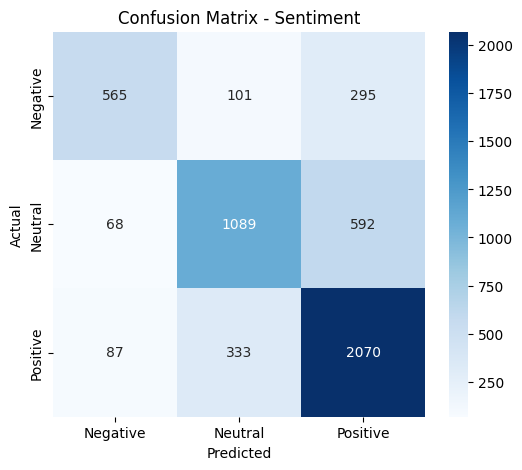

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(sent_true, sent_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_sent.classes_,
            yticklabels=le_sent.classes_)
plt.title("Confusion Matrix - Sentiment")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Penjelasan:

*   Membuat confusion matrix untuk evaluasi visual.
*   Heatmap memudahkan melihat kelas mana yang sering salah.